In [1]:
from pyfaidx import Fasta

In [2]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"

genome = Fasta(fasta_file)

# Car2 locus
region = "chr3"
start = 14886273 - 515418
end = 14895143 + 524288

In [3]:
input_sequence = genome[region][start:end]

In [ ]:
# CTCF locus
# 	chr4	87368268	87368249	+	90.56	65.75 (the strongest by insertion score)
# ctcf_region = "chr4"
# ctcf_start = 87368249
# ctcf_end = 87368268

In [ ]:
# ctcf_sequence = genome[ctcf_region][ctcf_start:ctcf_end]

In [4]:
import numpy as np

In [5]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()

    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

    # Step 1: Encode the sequence to integers
    encoded_sequence = np.array([base_to_int[base] for base in sequence])

    # Step 2: One-hot encode the sequence
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    # Step 3: Expand the dimensions to [1, 4, sequence_length]
    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence

In [6]:
ohe_input_sequence = one_hot_encode_sequence(input_sequence)

In [7]:
import torch

In [8]:
# ohe_ctcf_sequence = one_hot_encode_sequence(ctcf_sequence)

ohe_tensor_loaded = torch.load("/scratch1/smaruj/ledidi_targets/car2_locus/ohe_strong_ctcf.pt")

# Move to GPU if needed
tensor_ctcf_sequence = ohe_tensor_loaded.to("cuda")

/tmp/SLURM_348849/ipykernel_2987340/1441785522.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ohe_tensor_loaded = torch.load("/scratch1/smaruj/ledidi_targets/car2_locus

In [9]:
# Reverse along the sequence length dimension (last dim)
ohe_reversed = torch.flip(ohe_tensor_loaded, dims=[-1])

# Swap A <-> T (0th <-> 3rd row) and C <-> G (1st <-> 2nd row)
ohe_rc = ohe_reversed.clone()  # Create a copy to modify
ohe_rc[0], ohe_rc[3] = ohe_reversed[3], ohe_reversed[0]  # Swap A & T
ohe_rc[1], ohe_rc[2] = ohe_reversed[2], ohe_reversed[1]  # Swap C & G

# Now ohe_rc contains the reverse complement
tensor_ctcf_sequence_rc = ohe_rc

print("Reverse complement shape:", tensor_ctcf_sequence_rc.shape)

Reverse complement shape: torch.Size([4, 60])


In [10]:
tensor_input_sequence = torch.tensor(ohe_input_sequence, dtype=torch.float32)

In [ ]:
# tensor_ctcf_sequence = torch.tensor(ohe_ctcf_sequence, dtype=torch.float32)

In [12]:
tensor_input_sequence.shape, tensor_ctcf_sequence_rc.shape

(torch.Size([1, 4, 1048576]), torch.Size([1, 4, 60]))

In [11]:
# tensor_ctcf_sequence = tensor_ctcf_sequence.unsqueeze(0)
tensor_ctcf_sequence_rc = tensor_ctcf_sequence_rc.unsqueeze(0)

In [13]:
bin_start, bin_end = 200, 410

In [14]:
cropping_applied = 32
bin_size = 2048

In [15]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model import SeqNN

In [16]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [17]:
# Load the entire model (architecture + weights)
model = torch.load("/home1/smaruj/pytorch_akita/loaded_tf_weights_human_1Mb_model.pth")

/tmp/SLURM_348849/ipykernel_2987340/645978866.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("/home1/smaruj/pytorch_akita/loaded_tf_weights_human_1Mb

In [18]:
model = model.to(device)

In [19]:
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (re_lu): ReLU()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 96, kernel_size=(11,), stride=(1,), padding=(5,), bias=False)
    (batch_norm): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size

In [20]:
from helper import plot_map, from_upper_triu

In [21]:
target_to_plot = 0

In [22]:
model.eval()
with torch.no_grad():
    ref_pred = model(tensor_input_sequence, training=False)

In [23]:
ref_matrix_to_plot = from_upper_triu(ref_pred[0, target_to_plot, :], matrix_len=448, num_diags=2)

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

Bin: 201


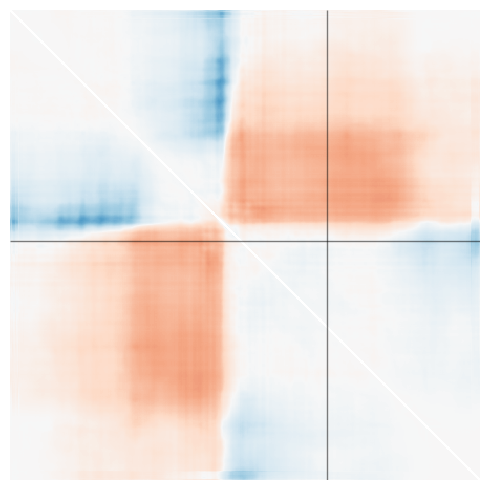

Bin: 226


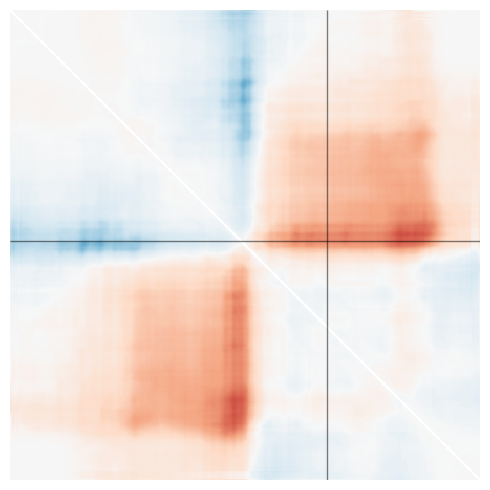

Bin: 291


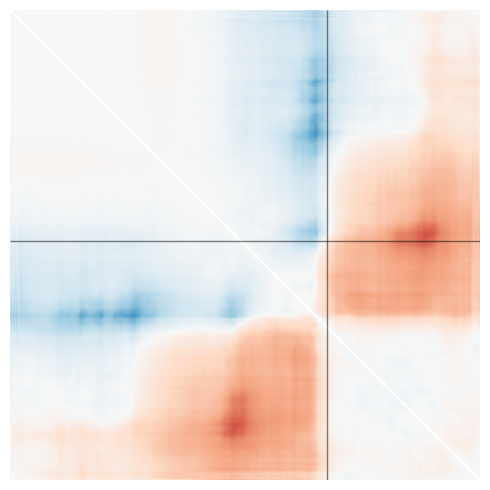

Bin: 305


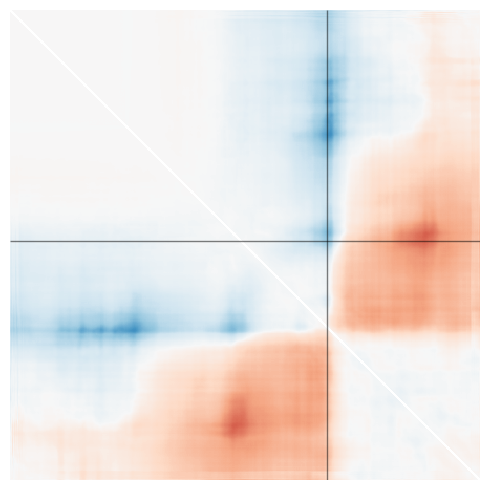

Bin: 375


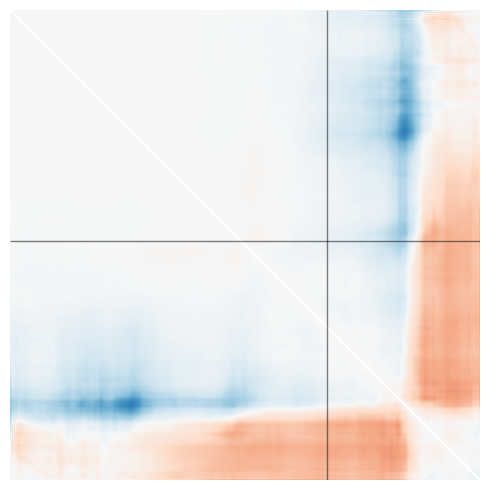

In [46]:
scd_list = []
dot_1_list = []
dot_2_list = []

# for bin in range(bin_start, bin_end + 1):
for bin in [201, 226, 291, 305, 375]:
    print("Bin:", bin)
    insert_start = int((bin + cropping_applied) * bin_size + 0.5 * bin_size - 30)
    insert_end = insert_start + 60

    modified_input_sequence = tensor_input_sequence.clone()
    # modified_input_sequence[:, :, insert_start:insert_end] = tensor_ctcf_sequence
    modified_input_sequence[:, :, insert_start:insert_end] = tensor_ctcf_sequence_rc

    model.eval()
    with torch.no_grad():
        pred = model(modified_input_sequence, training=False)

    # Convert pred to NumPy and ignore NaNs
    pred_np = pred.cpu().numpy()  # Move to CPU if on GPU

    # Convert to matrix while handling NaNs
    matrix_to_plot = from_upper_triu(pred_np[0, target_to_plot, :], matrix_len=448, num_diags=2)

    # plot_map(matrix_to_plot, vmin=-2, vmax=2)
    # plot_map(ref_matrix_to_plot - matrix_to_plot, vmin=-2, vmax=2)
    
    width=5
    height=5
    vmin = -2
    vmax = 2
    palette="RdBu_r"

    fig, axes = plt.subplots(1, 1, figsize=(width, height))

    sns.heatmap(
        ref_matrix_to_plot - matrix_to_plot,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes
    )

    axes.hlines(y=220, xmin=0, xmax=448, colors='black', linewidth=1.0, alpha = 0.5)

    # axes.vlines(x=272, ymin=0, ymax=448, colors='black', linewidth=1.0, alpha = 0.5)

    # # Highlight the 254th column
    axes.vlines(x=302, ymin=0, ymax=448, colors='black', linewidth=1.0, alpha = 0.5)

    plt.tight_layout()
    plt.show()
    
    # # Compute SCD while ignoring NaNs
    # diff = ref_matrix_to_plot - matrix_to_plot
    # scd = np.sqrt(np.nansum(np.square(diff)))  # Use np.nansum to ignore NaNs

    # # Compute dot averages while ignoring NaNs
    # dot_1_ave = np.nanmean(matrix_to_plot[219:222, 271:274])
    # dot_2_ave = np.nanmean(matrix_to_plot[219:222, 301:304])

    # # plot_map(matrix_to_plot, vmin=-0.6, vmax=0.6)
    
    # scd_list.append(scd)
    # dot_1_list.append(dot_1_ave)
    # dot_2_list.append(dot_2_ave)

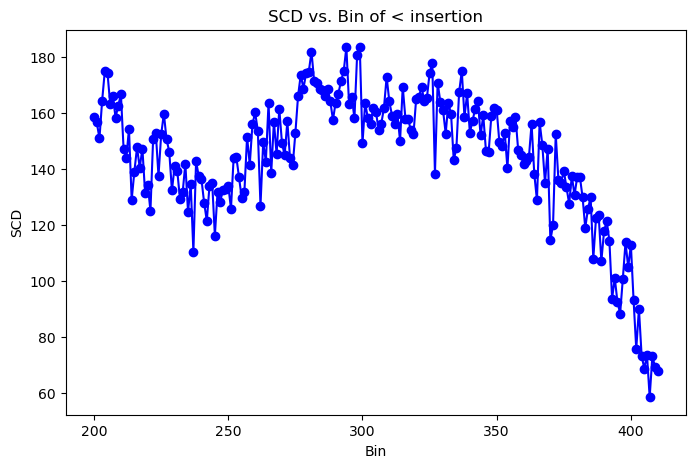

In [26]:
import matplotlib.pyplot as plt

# Generate x-axis values from 200 to 410
x_values = np.arange(200, 410+1)

# Ensure scd_list length matches x_values
assert len(scd_list) == len(x_values), "Mismatch in lengths of x and y values"

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x_values, scd_list, marker="o", linestyle="-", color="b")

# Label the axes
plt.xlabel("Bin")
plt.ylabel("SCD")

# Add a title (optional)
# plt.title("SCD vs. Bin of > insertion")
plt.title("SCD vs. Bin of < insertion")

# Show the plot
plt.show()


In [35]:
import pandas as pd

# Create a DataFrame
df = pd.DataFrame({"Bin": x_values, "dot": dot_2_list})
# df = pd.DataFrame({"Bin": x_values, "dot": scd_list})

In [39]:
# df[100:150]

In [ ]:
# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x_values, dot_1_list, marker="o", linestyle="-", color="r")

# Label the axes
plt.xlabel("Bin")
plt.ylabel("Dot P-E1 average")

plt.axvline(x=220, color="black", linestyle="--", linewidth=1.5, label="P")
plt.axvline(x=272, color="grey", linestyle="--", linewidth=1.5, label="E1")

# Add a title (optional)
# plt.title("Dot P-E1 average vs. Bin of > insertion")
plt.title("Dot P-E1 average vs. Bin of < insertion")

plt.legend()

# Show the plot
plt.show()

In [ ]:
# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x_values, dot_2_list, marker="o", linestyle="-", color="g")

# Label the axes
plt.xlabel("Bin")
plt.ylabel("Dot P-E2 average")

plt.axvline(x=220, color="black", linestyle="--", linewidth=1.5, label="P")
plt.axvline(x=302, color="grey", linestyle="--", linewidth=1.5, label="E2")

# Add a title (optional)
# plt.title("Dot P-E2 average vs. Bin of > insertion")
plt.title("Dot P-E2 average vs. Bin of < insertion")

plt.legend()

# Show the plot
plt.show()